Build and evaluate a Logistic Regression model to predict loan approval based on applicant demographic
and financial characteristics, while understanding probability prediction, coefficient interpretation,
log loss, regularization, class imbalance, threshold tuning, and classification metrics.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\amolm\Desktop\DATASETS\LOAN DEFAULT\loan_prediction_dataset.csv")

In [15]:
df

,age,income,credit_score,dependents,home_owner,loan_approved
0,54,100000.00,334,0,1,1
1,67,85233.42,593,2,1,1
2,29,16737.15,502,0,0,1
3,42,69332.50,367,3,0,0
4,58,28211.14,430,0,1,1
...,...,...,...,...,...,...
995,68,18279.98,379,3,0,0
996,41,8244.06,653,4,1,1
997,39,16194.69,460,2,1,1
998,52,38739.91,726,2,1,1


In [16]:
df.shape

(1000, 6)

In [17]:
df.head()

,age,income,credit_score,dependents,home_owner,loan_approved
0,54,100000.00,334,0,1,1
1,67,85233.42,593,2,1,1
2,29,16737.15,502,0,0,1
3,42,69332.50,367,3,0,0
4,58,28211.14,430,0,1,1


In [18]:
df.tail()

,age,income,credit_score,dependents,home_owner,loan_approved
995,68,18279.98,379,3,0,0
996,41,8244.06,653,4,1,1
997,39,16194.69,460,2,1,1
998,52,38739.91,726,2,1,1
999,24,11278.55,702,0,0,1


In [19]:
df.dtypes

age                int64
income           float64
credit_score       int64
dependents         int64
home_owner         int64
loan_approved      int64
dtype: object

In [20]:
df.isnull().sum()

age              0
income           0
credit_score     0
dependents       0
home_owner       0
loan_approved    0
dtype: int64

In [21]:
df.describe()

,age,income,credit_score,dependents,home_owner,loan_approved
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,44.54400,31943.240590,573.644000,2.027000,0.494000,0.782000
std,13.95345,28058.315386,163.781078,1.422074,0.500214,0.413094
min,20.00000,4000.000000,300.000000,0.000000,0.000000,0.000000
25%,33.00000,11057.325000,423.500000,1.000000,0.000000,1.000000
50%,44.00000,21712.035000,572.000000,2.000000,0.000000,1.000000
75%,57.00000,42369.575000,720.000000,3.000000,1.000000,1.000000
max,69.00000,100000.000000,849.000000,4.000000,1.000000,1.000000


In [22]:
df["loan_approved"].value_counts()

loan_approved
1    782
0    218
Name: count, dtype: int64

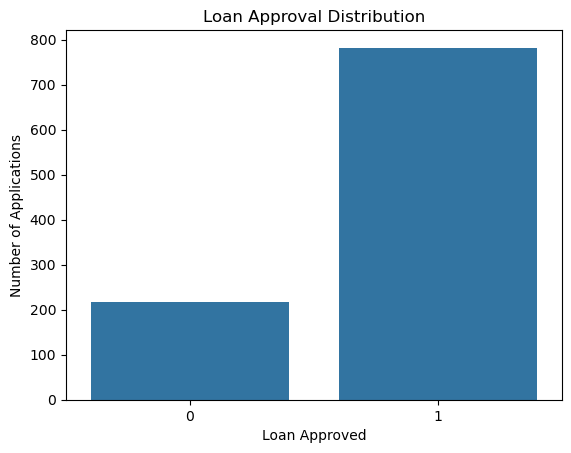

In [23]:
sns.countplot(data=df, x="loan_approved")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applications")
plt.show()

In [24]:
df["loan_approved"].value_counts(normalize=True) * 100

loan_approved
1    78.2
0    21.8
Name: proportion, dtype: float64

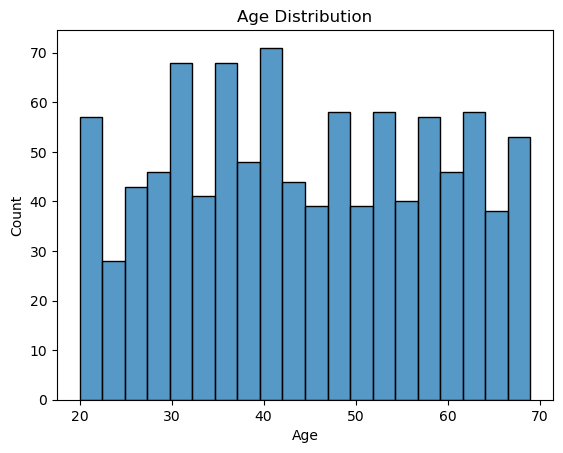

In [25]:
# Distribution of Age

sns.histplot(data=df, x="age", bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

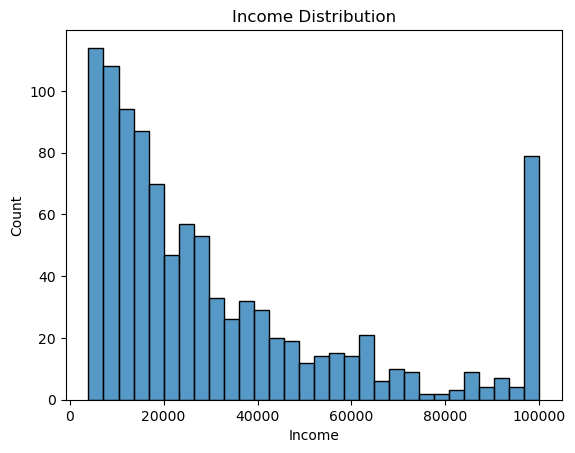

In [26]:
# Income distribution


sns.histplot(data=df, x="income", bins=30)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

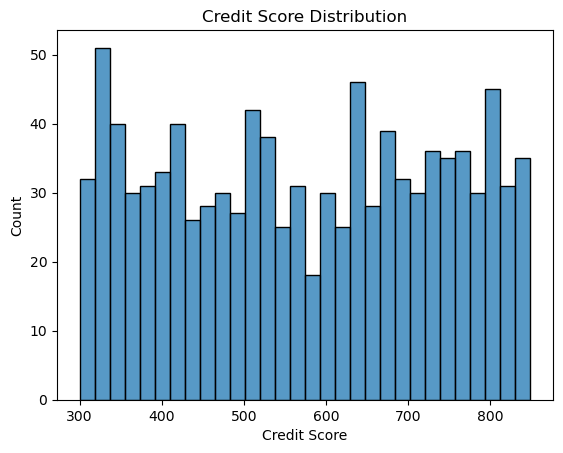

In [27]:
# Credit Score distribution
# credit score would reasonably be expected to have some relationship with loan approval.


sns.histplot(data=df, x="credit_score", bins=30)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

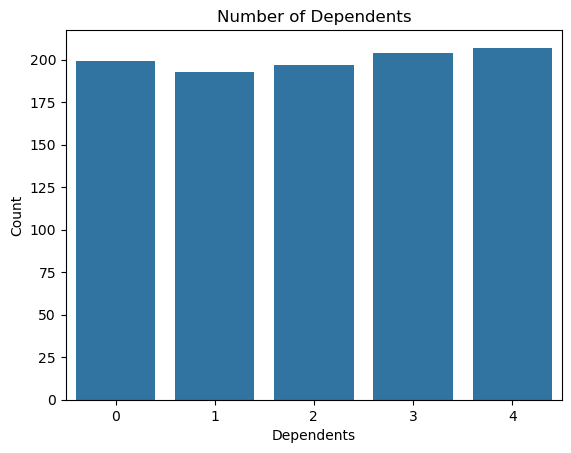

In [28]:
# Dependents


sns.countplot(data=df, x="dependents")

plt.title("Number of Dependents")
plt.xlabel("Dependents")
plt.ylabel("Count")
plt.show()

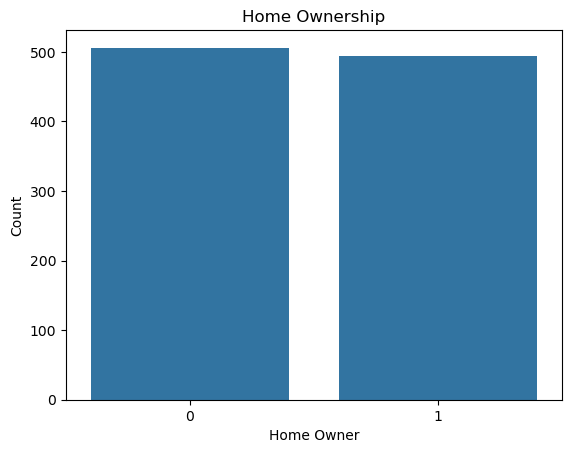

In [29]:
# Home ownership


sns.countplot(data=df, x="home_owner")

plt.title("Home Ownership")
plt.xlabel("Home Owner")
plt.ylabel("Count")
plt.show()

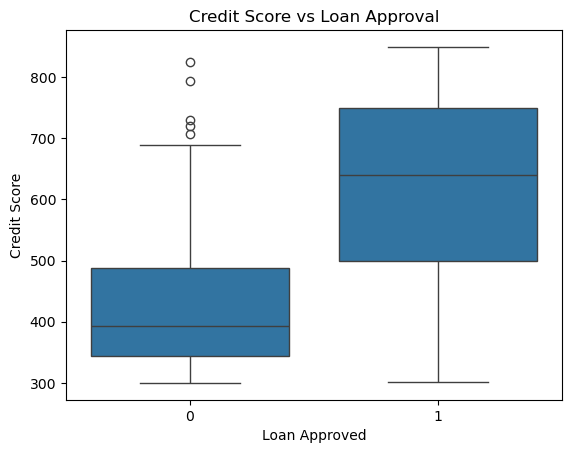

In [30]:
# Credit Score vs Approval
# Do approved and rejected applicants have different credit-score distributions?
# If the distributions differ substantially, credit score may be useful for prediction.

sns.boxplot(
    data=df,
    x="loan_approved",
    y="credit_score"
)

plt.title("Credit Score vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")
plt.show()

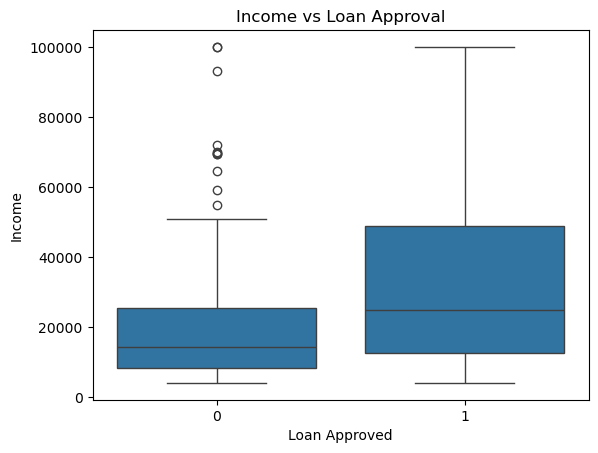

In [31]:
# Income vs Approval


sns.boxplot(
    data=df,
    x="loan_approved",
    y="income"
)

plt.title("Income vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Income")
plt.show()

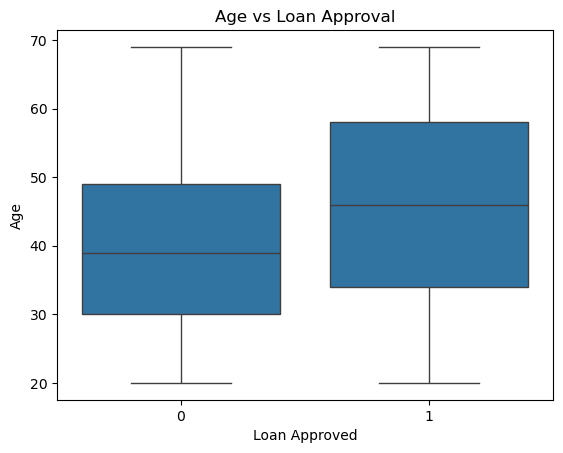

In [32]:
# Age vs Approval
# This tells us whether age appears to differ between approved and rejected applications.

sns.boxplot(
    data=df,
    x="loan_approved",
    y="age"
)

plt.title("Age vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Age")
plt.show()

In [33]:
# Home Ownership vs Approval
# This time use a cross-tabulation
# Within homeowners, what percentage were approved?
# Within non-homeowners, what percentage were approved?

pd.crosstab(
    df["home_owner"],
    df["loan_approved"],
    normalize="index"
) * 100

loan_approved,0,1
home_owner,,
0,27.667984,72.332016
1,15.789474,84.210526


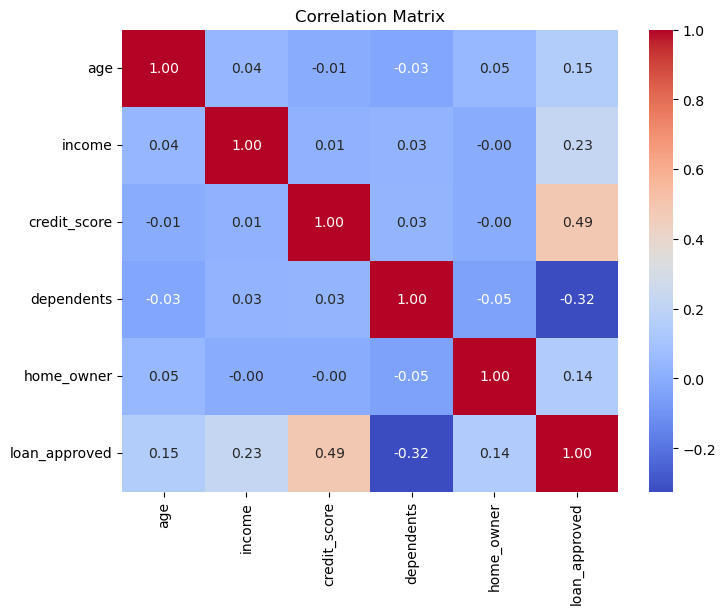

In [34]:
# Correlation matrix


corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


# This gives us the pairwise linear correlation between variables.
# Correlation does not prove causation.
# correlation is not the same thing as Logistic Regression's coefficient.
# A feature can have a weak simple correlation with the target while still contributing useful information in
  a multivariable Logistic Regression model.

In [35]:
# Check duplicate rows

df.duplicated().sum()

# If the result is 0, there are no exact duplicate rows.

# We don't want duplicated observations accidentally influencing our model.

np.int64(0)

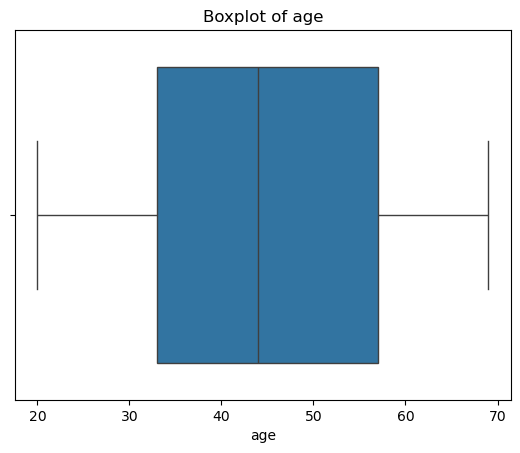

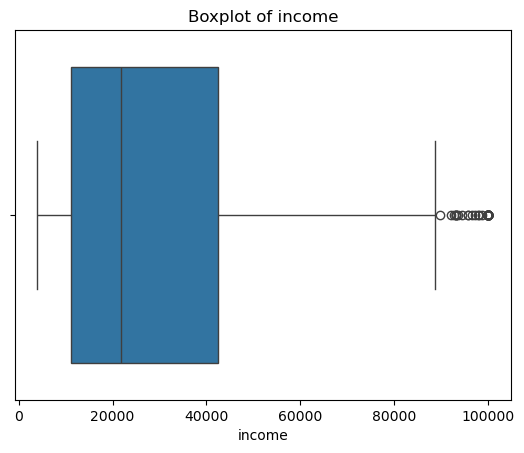

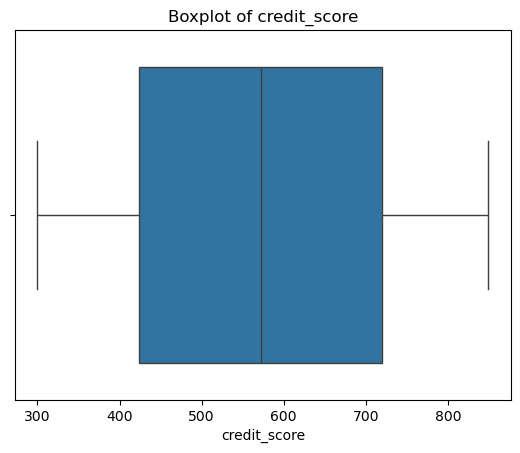

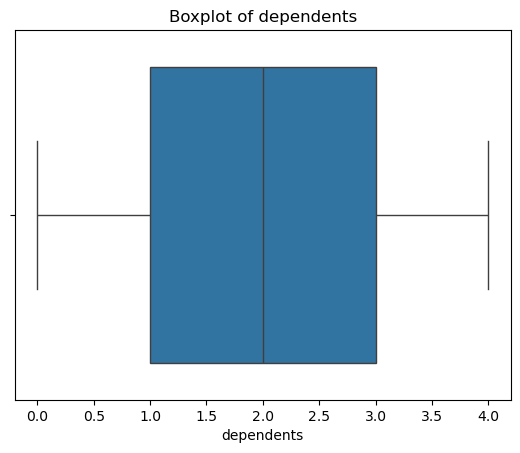

In [36]:
# Check outliers

features = [
    "age",
    "income",
    "credit_score",
    "dependents"
]

for col in features:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Define X and y
Our dataset:

age
income
credit_score
dependents
home_owner
loan_approved
The first five are inputs. loan_approved is the target.

In [37]:
X = df[
    [
        "age",
        "income",
        "credit_score",
        "dependents",
        "home_owner"
    ]
]

y = df["loan_approved"]

In [39]:
# Check X and y

print(X.shape)
print(y.shape)

(1000, 5)
(1000,)


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [42]:
random_state=42

In [43]:
# Verify the split

print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(800, 5)
(200, 5)
loan_approved
1    0.7825
0    0.2175
Name: proportion, dtype: float64
loan_approved
1    0.78
0    0.22
Name: proportion, dtype: float64


In [44]:
# Verify the split


print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(800, 5)
(200, 5)
loan_approved
1    0.7825
0    0.2175
Name: proportion, dtype: float64
loan_approved
1    0.78
0    0.22
Name: proportion, dtype: float64


In [45]:
# Build the preprocessing pipeline

# Instead of manually scaling everything, we'll use a Pipeline.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression())
])

In [48]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv(r"C:\Users\amolm\Desktop\DATASETS\LOAN DEFAULT\loan_prediction_dataset.csv")

# Features
X = df[
    [
        "age",
        "income",
        "credit_score",
        "dependents",
        "home_owner"
    ]
]

# Target
y = df["loan_approved"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Logistic Regression Pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression())
])

In [49]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 5)
X_test: (200, 5)
y_train: (800,)
y_test: (200,)


In [50]:
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logistic_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [51]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 1]


In [52]:
y_prob = model.predict_proba(X_test)

print(y_prob[:10])

[[9.95107790e-01 4.89221019e-03]
 [1.04961715e-01 8.95038285e-01]
 [4.14917301e-02 9.58508270e-01]
 [1.24731198e-04 9.99875269e-01]
 [1.59744910e-01 8.40255090e-01]
 [1.00064273e-02 9.89993573e-01]
 [4.34458645e-02 9.56554135e-01]
 [9.94376279e-01 5.62372134e-03]
 [1.49134900e-02 9.85086510e-01]
 [9.45321522e-01 5.46784778e-02]]


In [53]:
# Verify predict() ourselves

# Take the probability of class 1

y_prob_class1 = model.predict_proba(X_test)[:, 1]

print(y_prob_class1[:10])

[0.00489221 0.89503829 0.95850827 0.99987527 0.84025509 0.98999357
 0.95655414 0.00562372 0.98508651 0.05467848]


In [54]:
manual_pred = (y_prob_class1 >= 0.5).astype(int)

print(manual_pred[:10])

[0 1 1 1 1 1 1 0 1 0]


In [55]:
print(y_pred[:10])
print(manual_pred[:10])

[0 1 1 1 1 1 1 0 1 0]
[0 1 1 1 1 1 1 0 1 0]


In [56]:
# Now look at the actual predictions
# Create a small table:

results = pd.DataFrame({
    "actual": y_test.values,
    "probability_approved": y_prob_class1,
    "predicted": y_pred
})

print(results.head(15))

    actual  probability_approved  predicted
0        0              0.004892          0
1        1              0.895038          1
2        1              0.958508          1
3        1              0.999875          1
4        1              0.840255          1
5        1              0.989994          1
6        1              0.956554          1
7        0              0.005624          0
8        1              0.985087          1
9        0              0.054678          0
10       1              0.585924          1
11       1              0.999960          1
12       0              0.143727          0
13       1              0.737397          1
14       1              0.999256          1


In [58]:
# Inspect the coefficients
# We're using a Pipeline, we need to access the Logistic Regression model inside it.


lr = model.named_steps["logistic_regression"]

In [59]:
print(lr.coef_)

[[ 0.69553416  1.8987709   3.06919944 -2.03921849  0.80371188]]


In [60]:
# Inspect the intercept

print(lr.intercept_)

[3.85077572]


In [61]:
LogisticRegression()

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [62]:
# Let's extract our actual coefficients


lr = model.named_steps["logistic_regression"]

coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_[0]
})

coefficients

,feature,coefficient
0,age,0.695534
1,income,1.898771
2,credit_score,3.069199
3,dependents,-2.039218
4,home_owner,0.803712


In [63]:
# Let's extract our actual coefficients


lr = model.named_steps["logistic_regression"]

coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_[0]
})

coefficients

,feature,coefficient
0,age,0.695534
1,income,1.898771
2,credit_score,3.069199
3,dependents,-2.039218
4,home_owner,0.803712


In [64]:
# Calculate Odds Ratios


coefficients["odds_ratio"] = np.exp(
    coefficients["coefficient"]
)

coefficients

,feature,coefficient,odds_ratio
0,age,0.695534,2.004780
1,income,1.898771,6.677682
2,credit_score,3.069199,21.524664
3,dependents,-2.039218,0.130130
4,home_owner,0.803712,2.233817


In [65]:
# Calculate Odds Ratios


coefficients["odds_ratio"] = np.exp(
    coefficients["coefficient"]
)

coefficients

,feature,coefficient,odds_ratio
0,age,0.695534,2.004780
1,income,1.898771,6.677682
2,credit_score,3.069199,21.524664
3,dependents,-2.039218,0.130130
4,home_owner,0.803712,2.233817


In [66]:
# Import evaluation metrics


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    log_loss
)

In [67]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.86


In [68]:
# Confusion Matrix

# This is one of the most important concepts in classification.


cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 28  16]
 [ 12 144]]


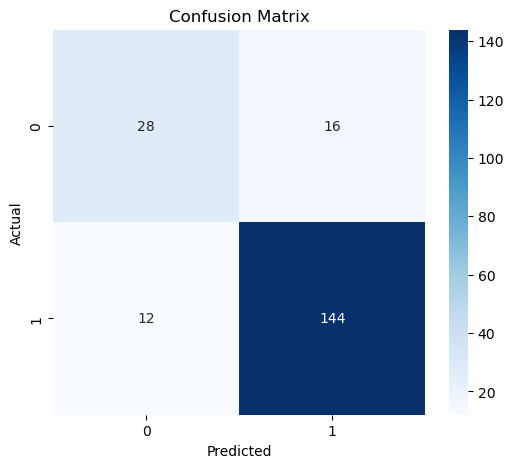

In [69]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [70]:
# Precision


precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.9


In [71]:
# Recall


recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9230769230769231


In [72]:
# F1 Score


f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9113924050632911


In [74]:
roc_auc_score(y_test, y_pred)

0.7797202797202797

In [76]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob.shape)

(200,)


In [77]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.939539627039627


In [78]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
loss = log_loss(y_test, y_prob)

print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Log Loss :", loss)

Precision: 0.9
Recall   : 0.9230769230769231
F1 Score : 0.9113924050632911
Log Loss : 0.25105450059585044


In [79]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 28  16]
 [ 12 144]]


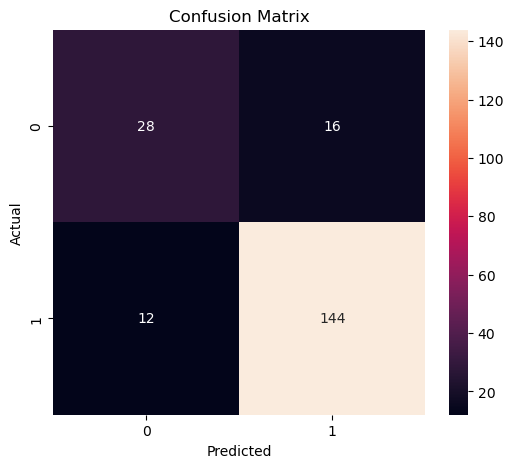

In [80]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Prediction code

In [81]:
import pandas as pd

# -----------------------------------------
# Enter applicant information
# -----------------------------------------

age = 35
income = 50000
credit_score = 700
dependents = 1
home_owner = 1


# -----------------------------------------
# Create input DataFrame
# -----------------------------------------

new_applicant = pd.DataFrame({
    "age": [age],
    "income": [income],
    "credit_score": [credit_score],
    "dependents": [dependents],
    "home_owner": [home_owner]
})


# -----------------------------------------
# Predict probability
# -----------------------------------------

probabilities = model.predict_proba(new_applicant)

probability_not_approved = probabilities[0][0]
probability_approved = probabilities[0][1]


# -----------------------------------------
# Final prediction
# -----------------------------------------

prediction = model.predict(new_applicant)[0]


# -----------------------------------------
# Display result
# -----------------------------------------

print("Applicant Details")
print("-----------------")
print("Age          :", age)
print("Income       :", income)
print("Credit Score :", credit_score)
print("Dependents   :", dependents)
print("Home Owner   :", home_owner)

print("\nPrediction")
print("----------")
print("Approval Probability :", round(probability_approved * 100, 2), "%")
print("Rejection Probability:", round(probability_not_approved * 100, 2), "%")

if prediction == 1:
    print("Final Decision       : LOAN APPROVED")
else:
    print("Final Decision       : LOAN NOT APPROVED")

Applicant Details
-----------------
Age          : 35
Income       : 50000
Credit Score : 700
Dependents   : 1
Home Owner   : 1

Prediction
----------
Approval Probability : 99.99 %
Rejection Probability: 0.01 %
Final Decision       : LOAN APPROVED


In [82]:
def predict_loan_approval(
    age,
    income,
    credit_score,
    dependents,
    home_owner
):
    
    new_applicant = pd.DataFrame({
        "age": [age],
        "income": [income],
        "credit_score": [credit_score],
        "dependents": [dependents],
        "home_owner": [home_owner]
    })
    
    # Probability
    probabilities = model.predict_proba(new_applicant)[0]
    
    probability_not_approved = probabilities[0]
    probability_approved = probabilities[1]
    
    # Class prediction
    prediction = model.predict(new_applicant)[0]
    
    print("===================================")
    print("       LOAN APPROVAL PREDICTION")
    print("===================================")
    
    print(f"Age             : {age}")
    print(f"Income          : {income}")
    print(f"Credit Score    : {credit_score}")
    print(f"Dependents      : {dependents}")
    print(f"Home Owner      : {home_owner}")
    
    print("\nPrediction")
    print("-----------------------------------")
    print(
        f"Approval Chance : "
        f"{probability_approved * 100:.2f}%"
    )
    
    print(
        f"Rejection Chance: "
        f"{probability_not_approved * 100:.2f}%"
    )
    
    if prediction == 1:
        print("Decision        : LOAN APPROVED")
    else:
        print("Decision        : LOAN NOT APPROVED")
    
    print("===================================")

In [83]:
predict_loan_approval(
    age=35,
    income=50000,
    credit_score=700,
    dependents=1,
    home_owner=1
)

       LOAN APPROVAL PREDICTION
Age             : 35
Income          : 50000
Credit Score    : 700
Dependents      : 1
Home Owner      : 1

Prediction
-----------------------------------
Approval Chance : 99.99%
Rejection Chance: 0.01%
Decision        : LOAN APPROVED


In [84]:
## Applicant 1 — Strong profile

predict_loan_approval(
    age=40,
    income=80000,
    credit_score=780,
    dependents=1,
    home_owner=1
)

       LOAN APPROVAL PREDICTION
Age             : 40
Income          : 80000
Credit Score    : 780
Dependents      : 1
Home Owner      : 1

Prediction
-----------------------------------
Approval Chance : 100.00%
Rejection Chance: 0.00%
Decision        : LOAN APPROVED


In [85]:
## Applicant 2 — Weaker profile


predict_loan_approval(
    age=25,
    income=20000,
    credit_score=400,
    dependents=4,
    home_owner=0
)

       LOAN APPROVAL PREDICTION
Age             : 25
Income          : 20000
Credit Score    : 400
Dependents      : 4
Home Owner      : 0

Prediction
-----------------------------------
Approval Chance : 0.77%
Rejection Chance: 99.23%
Decision        : LOAN NOT APPROVED


In [86]:
## Applicant 3 — Middle profile

predict_loan_approval(
    age=35,
    income=40000,
    credit_score=600,
    dependents=2,
    home_owner=0
)

       LOAN APPROVAL PREDICTION
Age             : 35
Income          : 40000
Credit Score    : 600
Dependents      : 2
Home Owner      : 0

Prediction
-----------------------------------
Approval Chance : 97.37%
Rejection Chance: 2.63%
Decision        : LOAN APPROVED


In [87]:
# The most important experiment

# Now change only the credit score.

# Keep everything else fixed:

predict_loan_approval(
    age=35,
    income=50000,
    credit_score=400,
    dependents=1,
    home_owner=1
)

       LOAN APPROVAL PREDICTION
Age             : 35
Income          : 50000
Credit Score    : 400
Dependents      : 1
Home Owner      : 1

Prediction
-----------------------------------
Approval Chance : 97.22%
Rejection Chance: 2.78%
Decision        : LOAN APPROVED


In [88]:
predict_loan_approval(
    age=35,
    income=50000,
    credit_score=600,
    dependents=1,
    home_owner=1
)

       LOAN APPROVAL PREDICTION
Age             : 35
Income          : 50000
Credit Score    : 600
Dependents      : 1
Home Owner      : 1

Prediction
-----------------------------------
Approval Chance : 99.93%
Rejection Chance: 0.07%
Decision        : LOAN APPROVED


In [89]:
predict_loan_approval(
    age=35,
    income=50000,
    credit_score=800,
    dependents=1,
    home_owner=1
)

       LOAN APPROVAL PREDICTION
Age             : 35
Income          : 50000
Credit Score    : 800
Dependents      : 1
Home Owner      : 1

Prediction
-----------------------------------
Approval Chance : 100.00%
Rejection Chance: 0.00%
Decision        : LOAN APPROVED
